# BOLD5000 fMRI Dataset Feasibility Test

This notebook tests:
1. Data access from OpenNeuro
2. Loading and viewing fMRI data
3. Loading stimulus labels
4. Visualizing brain activity
5. Fetching atlas for GNN nodes

NOTE: This was done using an AI agent : it is a quick test that we are able to obtain and process the data as needed. 
If this works, we are able to go ahead with the project.

In [1]:
# Step 0: Import necessary libraries
import os
import subprocess
import pandas as pd
import nibabel as nib
import nilearn
from nilearn import image, plotting, datasets
import matplotlib.pyplot as plt
import numpy as np

print("✓ All libraries imported successfully")
print(f"Nilearn version: {nilearn.__version__}")

✓ All libraries imported successfully
Nilearn version: 0.12.1


In [2]:
# Create directories for downloaded data
data_dir = "bold5000_sample"
os.makedirs(data_dir, exist_ok=True)
print(f"✓ Created directory: {data_dir}")

✓ Created directory: bold5000_sample


## Step 1: Download Sample Data from OpenNeuro

Downloading ONE functional run and ONE events file from BOLD5000 dataset.

In [3]:
# Download Functional Data (fMRI scan)
s3_bucket = "s3://openneuro.org/ds001499"
functional_file = "sub-CSI1/ses-01/func/sub-CSI1_ses-01_task-5000scenes_run-01_bold.nii.gz"
local_functional = os.path.join(data_dir, "bold.nii.gz")

print(f"Downloading functional data...")
result = subprocess.run(
    ["aws", "s3", "cp", f"{s3_bucket}/{functional_file}", local_functional, "--no-sign-request"],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f"✓ Downloaded: {local_functional}")
    print(f"  File size: {os.path.getsize(local_functional) / (1024*1024):.2f} MB")
else:
    print(f"✗ Error downloading functional data:")
    print(result.stderr)

✓ Downloaded: bold5000_sample/bold.nii.gz
  File size: 149.99 MB


In [4]:
# Download Events File (labels/stimulus info)
events_file = "sub-CSI1/ses-01/func/sub-CSI1_ses-01_task-5000scenes_run-01_events.tsv"
local_events = os.path.join(data_dir, "events.tsv")

print(f"Downloading events/labels file...")
result = subprocess.run(
    ["aws", "s3", "cp", f"{s3_bucket}/{events_file}", local_events, "--no-sign-request"],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f"✓ Downloaded: {local_events}")
    print(f"  File size: {os.path.getsize(local_events)} bytes")
else:
    print(f"✗ Error downloading events file:")
    print(result.stderr)

✓ Downloaded: bold5000_sample/events.tsv
  File size: 4061 bytes


## Step 2: Load and Examine Labels (Events File)

In [5]:
# Load the events TSV file
events_df = pd.read_csv(local_events, sep='\t')

print("✓ Events file loaded successfully!")
print(f"\nDataFrame shape: {events_df.shape}")
print(f"\nColumn names:")
print(events_df.columns.tolist())

✓ Events file loaded successfully!

DataFrame shape: (37, 13)

Column names:
['onset', 'duration', 'Subj', 'Sess', 'Run', 'Trial', 'ImgName', 'ImgType', 'StimOn(s)', 'StimOff(s)', 'Response', 'RT', 'stim_file']


In [6]:
# Print the first 5 trials to see stimulus (image names)
print("\n" + "="*60)
print("FIRST 5 TRIALS - Image Stimuli:")
print("="*60)

# Display the first few rows with all columns
print(events_df.head())

print("\n" + "="*60)
print("Stimulus names for first 5 trials:")
print("="*60)
if 'stimulus' in events_df.columns:
    for i, stim in enumerate(events_df['stimulus'].head(), 1):
        print(f"Trial {i}: {stim}")
elif 'stim_file' in events_df.columns:
    for i, stim in enumerate(events_df['stim_file'].head(), 1):
        print(f"Trial {i}: {stim}")
else:
    print("Note: Looking for stimulus column...")
    print(f"Available columns: {events_df.columns.tolist()}")


FIRST 5 TRIALS - Image Stimuli:
     onset  duration  Subj  Sess  Run  Trial                          ImgName  \
0   6.0367    0.9678     1     1    1      1             n01930112_19568.JPEG   
1  16.0122    0.9837     1     1    1      2             n03733281_29214.JPEG   
2  26.0037    1.0009     1     1    1      3              n07695742_5848.JPEG   
3  36.0121    0.9844     1     1    1      4  COCO_train2014_000000420713.jpg   
4  46.0038    1.0008     1     1    1      5  COCO_train2014_000000488558.jpg   

    ImgType  StimOn(s)  StimOff(s)  Response      RT  \
0  imagenet     6.0367      7.0045         2  3.6309   
1  imagenet    16.0122     16.9959         2  4.2031   
2  imagenet    26.0037     27.0046         1  1.8948   
3      coco    36.0121     36.9965         1  2.4701   
4      coco    46.0038     47.0046         1  2.8065   

                         stim_file  
0             n01930112_19568.JPEG  
1             n03733281_29214.JPEG  
2              n07695742_5848.JP

## Step 3: Load and Examine Brain Data (fMRI)

In [7]:
# Load the fMRI data using nilearn
print("Loading fMRI data (this may take a moment)...")
fmri_img = image.load_img(local_functional)

print("✓ fMRI data loaded successfully!")
print(f"\nData shape: {fmri_img.shape}")
print(f"  - Spatial dimensions (X, Y, Z): {fmri_img.shape[:3]}")
print(f"  - Time points: {fmri_img.shape[3]}")
print(f"\nVoxel size (mm): {fmri_img.header.get_zooms()[:3]}")
print(f"TR (seconds): {fmri_img.header.get_zooms()[3]}")

Loading fMRI data (this may take a moment)...
✓ fMRI data loaded successfully!

Data shape: (106, 106, 69, 194)
  - Spatial dimensions (X, Y, Z): (106, 106, 69)
  - Time points: 194

Voxel size (mm): (np.float32(2.0), np.float32(2.0), np.float32(2.0))
TR (seconds): 2.0


## Step 4: Visualize Brain Data

Plotting the first timepoint of the fMRI scan...
(This is the brain image at the beginning of the experiment)


/var/folders/wf/x89_kbv94dz4zpg4wy86jj4c0000gn/T/ipykernel_30509/4053646155.py:9: UserWarning: Casting data from int32 to float32
  display = plotting.plot_epi(first_volume,



✓ Brain visualization saved as: brain_check.png


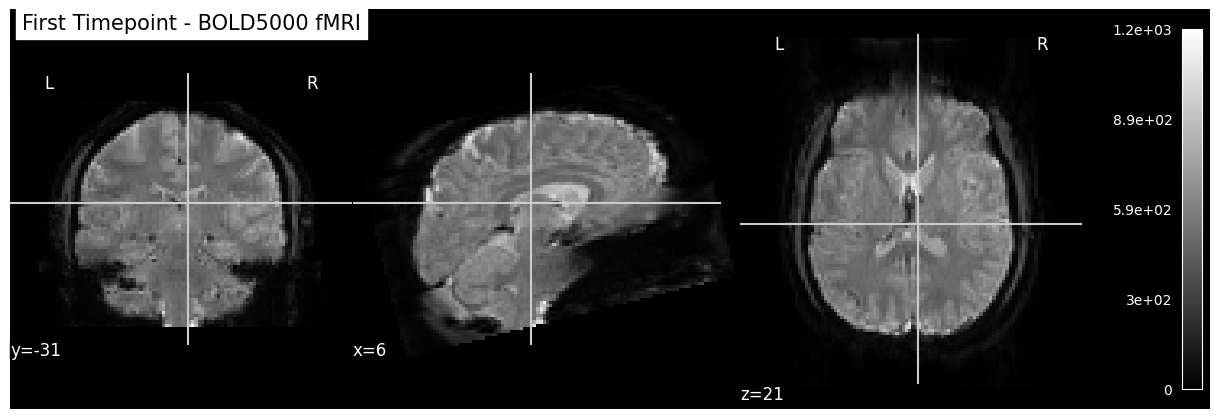

In [8]:
# Extract the first timepoint (index 0)
first_volume = image.index_img(fmri_img, 0)

print("Plotting the first timepoint of the fMRI scan...")
print("(This is the brain image at the beginning of the experiment)")

# Plot using nilearn
fig = plt.figure(figsize=(12, 4))
display = plotting.plot_epi(first_volume, 
                            title="First Timepoint - BOLD5000 fMRI",
                            figure=fig,
                            cmap='gray')

# Save the plot
output_file = "brain_check.png"
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"\n✓ Brain visualization saved as: {output_file}")

plt.show()

## Step 5: Fetch Brain Atlas (for GNN Nodes)

This atlas will define the brain regions (nodes) for the Graph Neural Network.

In [9]:
# Download the Schaefer 2018 atlas with 100 ROIs (regions of interest)
print("Fetching Schaefer 2018 atlas (100 ROIs)...")
print("(This defines 100 brain regions that can be used as nodes in a GNN)")

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7, resolution_mm=2)

print("\n✓ Atlas fetched successfully!")
print(f"\nAtlas map file: {atlas.maps}")
print(f"Number of regions: {len(atlas.labels)}")
print(f"\nFirst 10 region labels:")
for i, label in enumerate(atlas.labels[:10], 1):
    print(f"  {i}. {label}")

Fetching Schaefer 2018 atlas (100 ROIs)...
(This defines 100 brain regions that can be used as nodes in a GNN)
[fetch_atlas_schaefer_2018] Dataset found in /Users/mario/nilearn_data/schaefer_2018

✓ Atlas fetched successfully!

Atlas map file: /Users/mario/nilearn_data/schaefer_2018/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_2mm.nii.gz
Number of regions: 101

First 10 region labels:
  1. Background
  2. 7Networks_LH_Vis_1
  3. 7Networks_LH_Vis_2
  4. 7Networks_LH_Vis_3
  5. 7Networks_LH_Vis_4
  6. 7Networks_LH_Vis_5
  7. 7Networks_LH_Vis_6
  8. 7Networks_LH_Vis_7
  9. 7Networks_LH_Vis_8
  10. 7Networks_LH_Vis_9


## ✅ Feasibility Test Complete!

**Summary of what we verified:**
1. ✓ Access to BOLD5000 dataset from OpenNeuro
2. ✓ Load and examine stimulus labels (image names/classifications)
3. ✓ Load fMRI data with correct dimensions (X, Y, Z, Time)
4. ✓ Visualize brain activity
5. ✓ Fetch brain atlas (100 regions for GNN nodes)

**Next steps for your project:**
- Extract timeseries from each atlas region
- Build connectivity graphs between brain regions
- Create GNN to classify "Food" vs "Place" images based on brain activity

## Step 6: Atlas Extraction - Convert 3D Brain to 100-Node Features

This step extracts time series from each of the 100 brain regions defined by the atlas.
This is the critical step for converting raw fMRI data into GNN-ready features.

In [10]:
# Step 1: Load the Atlas (already loaded above, but let's verify)
from nilearn.maskers import NiftiLabelsMasker

print("Atlas Information:")
print(f"  Atlas map file: {atlas.maps}")
print(f"  Number of regions (including background): {len(atlas.labels)}")
print(f"  Actual brain regions (nodes): {len(atlas.labels) - 1}")  # Exclude background

Atlas Information:
  Atlas map file: /Users/mario/nilearn_data/schaefer_2018/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_2mm.nii.gz
  Number of regions (including background): 101
  Actual brain regions (nodes): 100


In [11]:
# Step 2: Initialize the NiftiLabelsMasker
# This will extract the average signal from each brain region
masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize=True,  # Standardize signals to zero mean and unit variance
    memory='nilearn_cache'  # Cache the fitted masker for faster re-runs
)

print("✓ NiftiLabelsMasker initialized")
print(f"  Standardization: Enabled")
print(f"  Caching: Enabled (nilearn_cache/)")

✓ NiftiLabelsMasker initialized
  Standardization: Enabled
  Caching: Enabled (nilearn_cache/)


In [12]:
# Step 3: Extract Time Series from the fMRI data
# This will take 30-60 seconds - be patient!
print("Extracting time series from fMRI data...")
print("(This may take 30-60 seconds...)")
print("")

import time
start_time = time.time()

# Extract the time series - masker computes average signal in each region
timeseries = masker.fit_transform(local_functional)

elapsed_time = time.time() - start_time

print(f"✓ Time series extraction complete!")
print(f"  Elapsed time: {elapsed_time:.1f} seconds")

Extracting time series from fMRI data...
(This may take 30-60 seconds...)

✓ Time series extraction complete!
  Elapsed time: 2.8 seconds


In [13]:
# Step 4: Verify & Print the results
print("=" * 60)
print("TIME SERIES MATRIX INFORMATION")
print("=" * 60)
print(f"\nMatrix shape: {timeseries.shape}")
print(f"  Expected: (Timepoints, Regions)")
print(f"  Got: ({timeseries.shape[0]} timepoints, {timeseries.shape[1]} regions)")

if timeseries.shape == (194, 100):
    print("\n✓ PERFECT! Shape is exactly (194, 100)")
elif timeseries.shape[1] == 100:
    print(f"\n✓ GOOD! Got 100 regions (timepoints: {timeseries.shape[0]})")
else:
    print(f"\n⚠ Note: Got {timeseries.shape[1]} regions (expected 100)")

print("\n" + "=" * 60)
print("FIRST 5 VALUES OF REGION 1 (Node 1):")
print("=" * 60)
print(f"These are standardized BOLD signals over time:")
for i in range(5):
    print(f"  Timepoint {i}: {timeseries[i, 0]:.6f}")

TIME SERIES MATRIX INFORMATION

Matrix shape: (194, 100)
  Expected: (Timepoints, Regions)
  Got: (194 timepoints, 100 regions)

✓ PERFECT! Shape is exactly (194, 100)

FIRST 5 VALUES OF REGION 1 (Node 1):
These are standardized BOLD signals over time:
  Timepoint 0: 2.512517
  Timepoint 1: 0.225955
  Timepoint 2: 1.867524
  Timepoint 3: 0.276542
  Timepoint 4: 0.541622


Creating visualization of time series matrix...

✓ Visualization saved as: timeseries_matrix.png


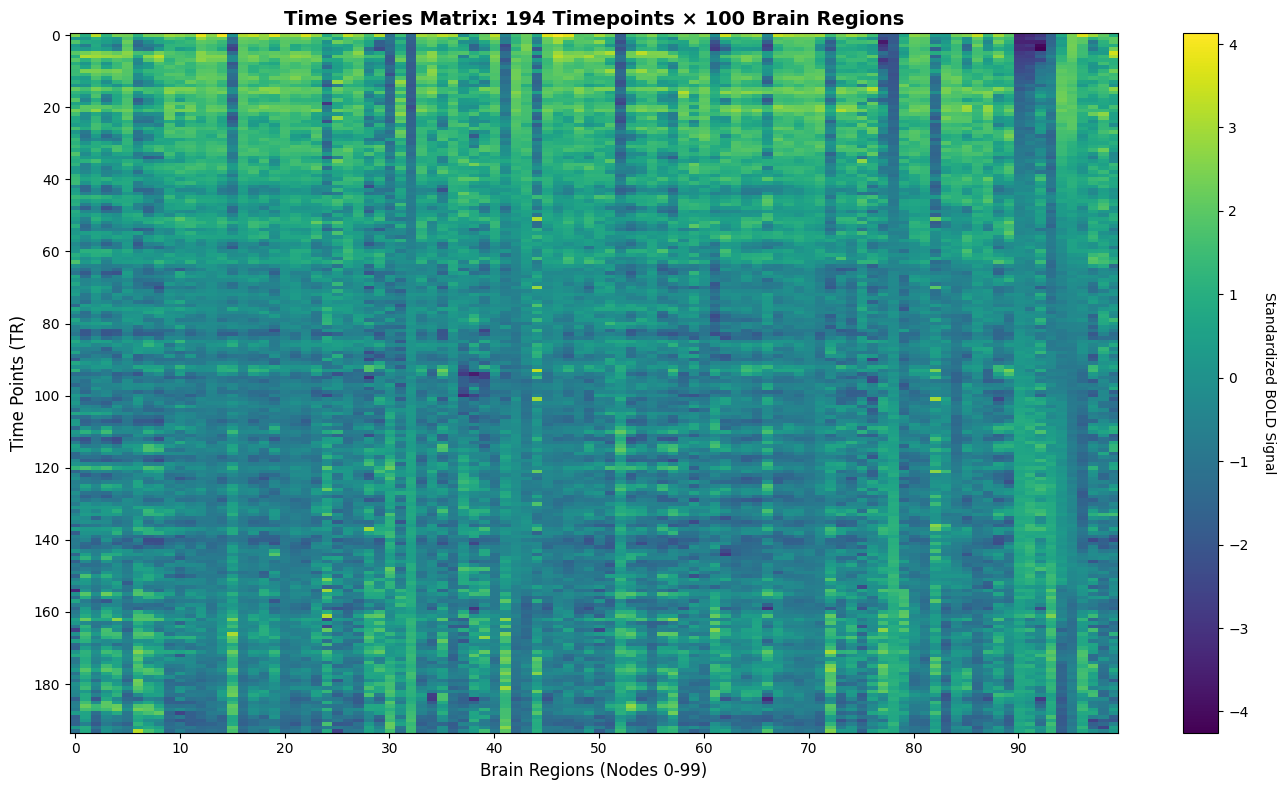


✓ SUCCESS: 3D Brain converted to 100-node features!


In [14]:
# Step 5: Visualize the Time Series Matrix
print("Creating visualization of time series matrix...")

fig, ax = plt.subplots(figsize=(14, 8))

# Plot the matrix: rows=time, columns=regions
im = ax.imshow(timeseries, aspect='auto', cmap='viridis', interpolation='nearest')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Standardized BOLD Signal', rotation=270, labelpad=20)

# Labels and title
ax.set_xlabel('Brain Regions (Nodes 0-99)', fontsize=12)
ax.set_ylabel('Time Points (TR)', fontsize=12)
ax.set_title('Time Series Matrix: 194 Timepoints × 100 Brain Regions', fontsize=14, fontweight='bold')

# Add grid for clarity
ax.set_xticks(np.arange(0, 100, 10))
ax.set_yticks(np.arange(0, timeseries.shape[0], 20))
ax.grid(False)

# Tight layout
plt.tight_layout()

# Save the figure
output_file = 'timeseries_matrix.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"\n✓ Visualization saved as: {output_file}")

plt.show()

print("\n" + "=" * 60)
print("✓ SUCCESS: 3D Brain converted to 100-node features!")
print("=" * 60)

## Step 7: Visualize GLM Beta Maps

This section visualizes the processed GLM beta maps to verify brain activation aligns with image stimuli.
Each beta map represents the estimated brain response to a specific image.

In [15]:
# Step 1: Setup paths and check if files exist
dataset_dir = "dataset"
glm_beta_file = os.path.join(dataset_dir, "CSI1_GLMbetas-TYPEA-ASSUMEHRF_ses-01.nii.gz")
events_file_glm = os.path.join(dataset_dir, "sub-CSI1_ses-01_task-5000scenes_run-01_events.tsv")

# Create dataset directory if it doesn't exist
os.makedirs(dataset_dir, exist_ok=True)
print(f"Dataset directory: {dataset_dir}")

# Check if GLM beta file exists
if os.path.exists(glm_beta_file):
    print(f"✓ GLM beta file found: {glm_beta_file}")
    file_size_mb = os.path.getsize(glm_beta_file) / (1024 * 1024)
    print(f"  File size: {file_size_mb:.2f} MB")
else:
    print(f"⚠ GLM beta file not found: {glm_beta_file}")
    print(f"  Please place the GLM file in the dataset/ directory")

# Check if events file exists in dataset folder, if not copy from bold5000_sample
if not os.path.exists(events_file_glm):
    if os.path.exists(local_events):
        import shutil
        shutil.copy(local_events, events_file_glm)
        print(f"✓ Copied events file to: {events_file_glm}")
    else:
        print(f"⚠ Events file not found. Will use: {local_events}")
        events_file_glm = local_events
else:
    print(f"✓ Events file found: {events_file_glm}")

Dataset directory: dataset
✓ GLM beta file found: dataset/CSI1_GLMbetas-TYPEA-ASSUMEHRF_ses-01.nii.gz
  File size: 260.01 MB
✓ Events file found: dataset/sub-CSI1_ses-01_task-5000scenes_run-01_events.tsv


In [16]:
# Step 2: Load the GLM Beta image (4D volume)
if os.path.exists(glm_beta_file):
    print("Loading GLM beta maps...")
    beta_img = image.load_img(glm_beta_file)
    
    print("✓ GLM beta image loaded successfully!")
    print(f"\nBeta image shape: {beta_img.shape}")
    print(f"  - Spatial dimensions (X, Y, Z): {beta_img.shape[:3]}")
    print(f"  - Number of beta maps (trials): {beta_img.shape[3]}")
else:
    print("Cannot proceed without GLM beta file.")
    print("Please place 'CSI1_GLMbetas-TYPEA-ASSUMEHRF_ses-01.nii.gz' in the dataset/ directory.")

Loading GLM beta maps...
✓ GLM beta image loaded successfully!

Beta image shape: (71, 89, 72, 370)
  - Spatial dimensions (X, Y, Z): (71, 89, 72)
  - Number of beta maps (trials): 370


In [17]:
# Step 3: Load the Events TSV file
events_glm_df = pd.read_csv(events_file_glm, sep='\t')

print("✓ Events file loaded")
print(f"Number of trials: {len(events_glm_df)}")
print(f"\nFirst 3 stimulus files:")
for i in range(min(3, len(events_glm_df))):
    # Try different column names for stimulus
    if 'stim_file' in events_glm_df.columns:
        stim_name = events_glm_df['stim_file'].iloc[i]
    elif 'stimulus' in events_glm_df.columns:
        stim_name = events_glm_df['stimulus'].iloc[i]
    elif 'ImgName' in events_glm_df.columns:
        stim_name = events_glm_df['ImgName'].iloc[i]
    else:
        stim_name = f"Trial {i}"
    print(f"  Trial {i}: {stim_name}")

✓ Events file loaded
Number of trials: 37

First 3 stimulus files:
  Trial 0: n01930112_19568.JPEG
  Trial 1: n03733281_29214.JPEG
  Trial 2: n07695742_5848.JPEG


VISUALIZING BETA MAPS

Creating mean beta image for background alignment...
✓ Mean image created

--- Processing Trial 0 ---
Stimulus: n01930112_19568.JPEG
  Data range: [-3814.97, 10628.48]
  Using vmax=3.28 for color scaling


/var/folders/wf/x89_kbv94dz4zpg4wy86jj4c0000gn/T/ipykernel_30509/353355469.py:10: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_beta = image.mean_img(beta_img)
/var/folders/wf/x89_kbv94dz4zpg4wy86jj4c0000gn/T/ipykernel_30509/353355469.py:46: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  display = plotting.plot_stat_map(


✓ Saved: beta_check_trial_0.png


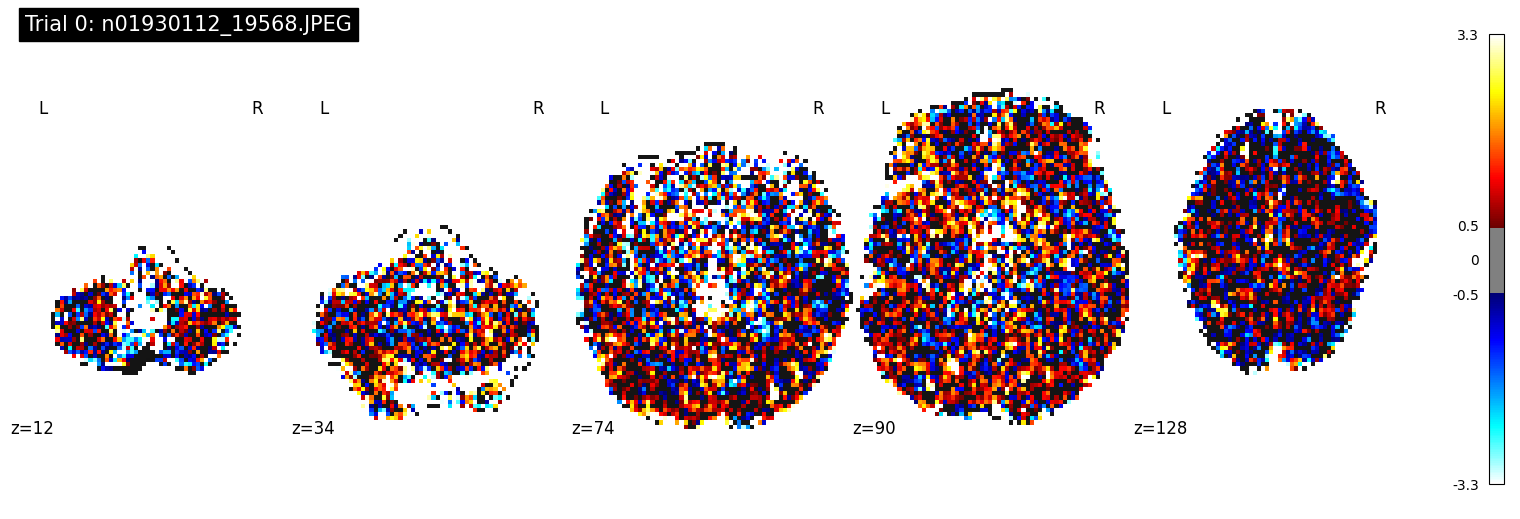


--- Processing Trial 1 ---
Stimulus: n03733281_29214.JPEG
  Data range: [-6987.56, 5995.98]
  Using vmax=3.37 for color scaling
✓ Saved: beta_check_trial_1.png


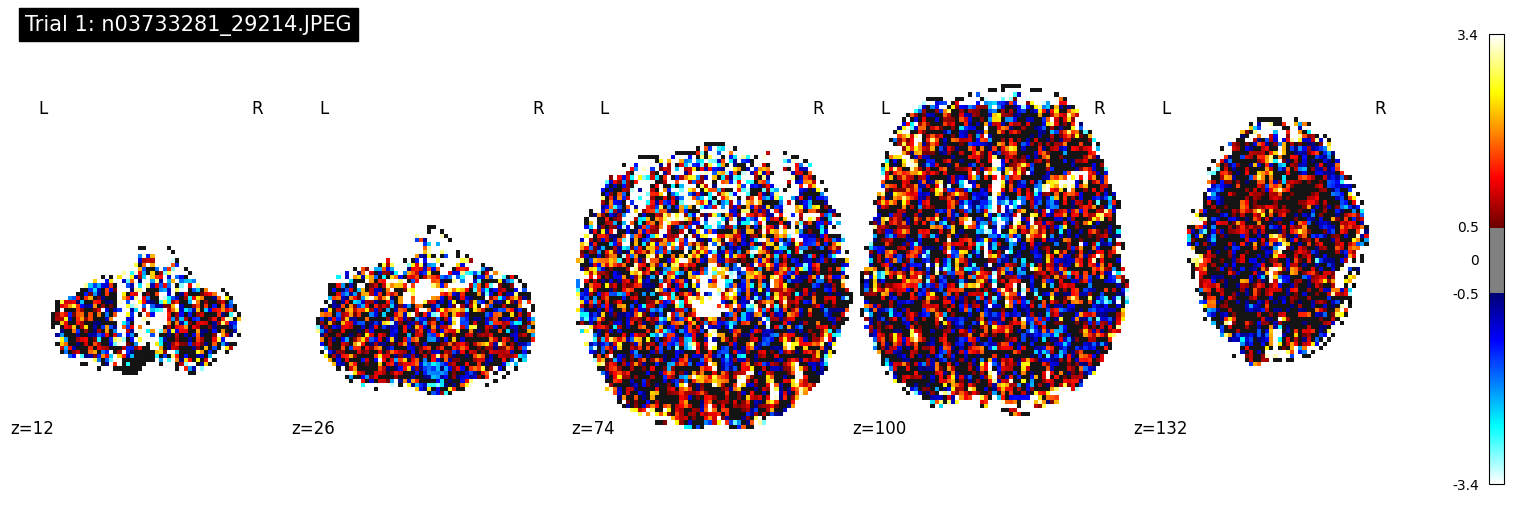


--- Processing Trial 2 ---
Stimulus: n07695742_5848.JPEG
  Data range: [-7204.51, 3878.44]
  Using vmax=3.50 for color scaling
✓ Saved: beta_check_trial_2.png


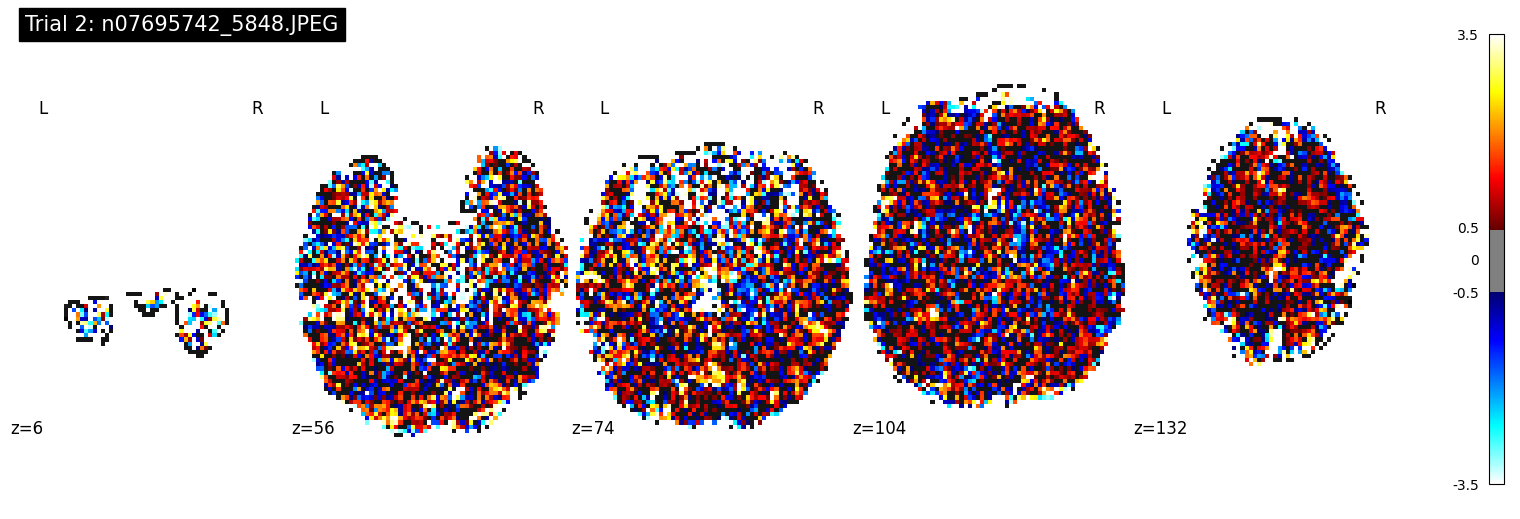


✓ ALL VISUALIZATIONS COMPLETE!


In [19]:
# Step 4: Visualize Beta Maps for First 3 Trials
if os.path.exists(glm_beta_file):
    print("=" * 70)
    print("VISUALIZING BETA MAPS")
    print("=" * 70)
    
    # Create a mean image from all betas to use as background
    # This ensures the background and overlay are in the same coordinate space
    print("\nCreating mean beta image for background alignment...")
    mean_beta = image.mean_img(beta_img)
    print("✓ Mean image created")
    
    # How many trials to visualize (change this as needed)
    num_trials = 3
    
    for i in range(num_trials):
        print(f"\n--- Processing Trial {i} ---")
        
        # Get the stimulus label
        if 'stim_file' in events_glm_df.columns:
            label_name = events_glm_df['stim_file'].iloc[i]
        elif 'stimulus' in events_glm_df.columns:
            label_name = events_glm_df['stimulus'].iloc[i]
        elif 'ImgName' in events_glm_df.columns:
            label_name = events_glm_df['ImgName'].iloc[i]
        else:
            label_name = f"Trial {i}"
        
        print(f"Stimulus: {label_name}")
        
        # Extract the i-th beta map (3D volume) from the 4D image
        beta_map_3d = image.index_img(beta_img, i)
        
        # Calculate statistics for this volume
        data = beta_map_3d.get_fdata()
        data_flat = data[~np.isnan(data)].flatten()
        vmax = np.percentile(np.abs(data_flat), 95)  # 95th percentile for color scaling
        
        print(f"  Data range: [{data_flat.min():.2f}, {data_flat.max():.2f}]")
        print(f"  Using vmax={vmax:.2f} for color scaling")
        
        # Create the visualization with multiple slices
        fig = plt.figure(figsize=(15, 5))
        
        # Plot the statistical map with aligned background
        display = plotting.plot_stat_map(
            beta_map_3d,
            bg_img=mean_beta,  # Use mean beta as background for proper alignment
            display_mode='z',  # Axial (top-down) slices
            cut_coords=5,      # Show 5 slices instead of 1
            title=f"Trial {i}: {label_name}",
            threshold=0.5,     # Lower threshold to show more activation
            vmax=vmax,         # Dynamic color scaling based on data
            cmap='cold_hot',   # Better colormap for positive/negative activations
            figure=fig,
            colorbar=True,
            black_bg=False,    # White background for better visibility
            dim=-0.5           # Dim the background slightly for better overlay visibility
        )
        
        # Save the figure
        output_filename = f"beta_check_trial_{i}.png"
        plt.savefig(output_filename, dpi=150, bbox_inches='tight')
        print(f"✓ Saved: {output_filename}")
        
        plt.show()
    
    print("\n" + "=" * 70)
    print("✓ ALL VISUALIZATIONS COMPLETE!")
    print("=" * 70)
else:
    print("⚠ Skipping visualization - GLM beta file not found.")

### Summary: Beta Map Visualization

Each visualization shows:
- **Title:** The stimulus image filename that was shown to the participant
- **Brain Map:** Statistical map showing brain regions with activation
- **Background:** Mean beta image used to ensure proper spatial alignment
- **Multiple Slices:** 5 axial (top-down) slices showing activation patterns across brain depth
- **Threshold:** 0.5 (lower threshold to show more activation patterns)
- **Color Scaling:** Dynamic vmax based on 95th percentile for better contrast
- **Colormap:** 'cold_hot' - red/yellow for positive activation, blue for negative

**Note on Alignment:** By using the mean beta image as background (`bg_img=mean_beta`), we ensure the colored activation overlays perfectly align with the brain structure, as both are in the same coordinate space.

**Note on Variations:** Different stimuli activate different brain regions, which is why activation patterns vary by image. This is expected - visual areas, object recognition areas, and semantic regions respond differently to foods, places, objects, etc.

## Step 8: Map Filenames to Object/Scene Labels

This section downloads mapping files and creates a system to convert filenames to human-readable labels:
- **ImageNet** (n########): Maps WordNet synset IDs to class names (e.g., "golden retriever", "pizza")
- **COCO** (COCO_train2014_###): Maps to object categories (multiple objects per image)
- **SUN** (scene names): Maps to scene categories (e.g., "kitchen", "bedroom")

In [20]:
# Step 1: Download ImageNet synset mapping file
# This maps WordNet IDs (like n01930112) to human-readable labels

import urllib.request
import json

# Create a mappings directory
mappings_dir = "label_mappings"
os.makedirs(mappings_dir, exist_ok=True)

# Download ImageNet class info
imagenet_mapping_file = os.path.join(mappings_dir, "imagenet_class_index.json")

if not os.path.exists(imagenet_mapping_file):
    print("Downloading ImageNet synset mappings...")
    url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
    try:
        urllib.request.urlretrieve(url, imagenet_mapping_file)
        print(f"✓ Downloaded: {imagenet_mapping_file}")
    except Exception as e:
        print(f"✗ Error downloading ImageNet mappings: {e}")
else:
    print(f"✓ ImageNet mappings already exist: {imagenet_mapping_file}")

# Load the ImageNet mappings
if os.path.exists(imagenet_mapping_file):
    with open(imagenet_mapping_file, 'r') as f:
        imagenet_idx_to_label = json.load(f)
    
    # Convert to synset ID -> label mapping
    imagenet_synset_to_label = {}
    for idx, (synset_id, label) in imagenet_idx_to_label.items():
        imagenet_synset_to_label[synset_id] = label
    
    print(f"✓ Loaded {len(imagenet_synset_to_label)} ImageNet class mappings")
    print(f"\nExample mappings:")
    for i, (synset, label) in enumerate(list(imagenet_synset_to_label.items())[:5]):
        print(f"  {synset} -> {label}")

✓ Downloaded: label_mappings/imagenet_class_index.json
✓ Loaded 1000 ImageNet class mappings

Example mappings:
  n01440764 -> tench
  n01443537 -> goldfish
  n01484850 -> great_white_shark
  n01491361 -> tiger_shark
  n01494475 -> hammerhead


In [21]:
# Step 2: Create a function to get labels from filenames

def get_label_from_filename(filename):
    """
    Extract human-readable label from BOLD5000 image filename.
    
    Handles:
    - ImageNet: n########_#####.JPEG -> class name
    - COCO: COCO_train2014_########.jpg -> "COCO image"
    - SUN: scene names or other formats
    
    Returns: (dataset, label, synset_id)
    """
    
    # ImageNet format: n########_#####.JPEG
    if filename.startswith('n') and '_' in filename:
        synset_id = filename.split('_')[0]  # Extract n########
        if synset_id in imagenet_synset_to_label:
            label = imagenet_synset_to_label[synset_id]
            return ('ImageNet', label, synset_id)
        else:
            return ('ImageNet', 'unknown_class', synset_id)
    
    # COCO format: COCO_train2014_########.jpg
    elif filename.startswith('COCO'):
        # For COCO, we'd need the full annotations to get object names
        # For now, just mark it as COCO
        image_id = filename.split('_')[-1].split('.')[0]
        return ('COCO', 'COCO_image', image_id)
    
    # SUN or other scene images
    else:
        # Could be a scene name or other format
        base_name = filename.rsplit('.', 1)[0]  # Remove extension
        return ('Scene/Other', base_name, base_name)

print("✓ Label extraction function created")
print("\nFunction usage: get_label_from_filename(filename)")

✓ Label extraction function created

Function usage: get_label_from_filename(filename)


In [22]:
# Step 3: Test the label extraction on our data

print("=" * 70)
print("TESTING LABEL EXTRACTION ON FIRST 10 TRIALS")
print("=" * 70)

# Get stimulus filenames
if 'stim_file' in events_glm_df.columns:
    stim_col = 'stim_file'
elif 'ImgName' in events_glm_df.columns:
    stim_col = 'ImgName'
else:
    stim_col = events_glm_df.columns[0]

for i in range(min(10, len(events_glm_df))):
    filename = events_glm_df[stim_col].iloc[i]
    dataset, label, identifier = get_label_from_filename(filename)
    
    print(f"\nTrial {i}:")
    print(f"  Filename:   {filename}")
    print(f"  Dataset:    {dataset}")
    print(f"  Label:      {label}")
    print(f"  ID:         {identifier}")

TESTING LABEL EXTRACTION ON FIRST 10 TRIALS

Trial 0:
  Filename:   n01930112_19568.JPEG
  Dataset:    ImageNet
  Label:      nematode
  ID:         n01930112

Trial 1:
  Filename:   n03733281_29214.JPEG
  Dataset:    ImageNet
  Label:      maze
  ID:         n03733281

Trial 2:
  Filename:   n07695742_5848.JPEG
  Dataset:    ImageNet
  Label:      pretzel
  ID:         n07695742

Trial 3:
  Filename:   COCO_train2014_000000420713.jpg
  Dataset:    COCO
  Label:      COCO_image
  ID:         000000420713

Trial 4:
  Filename:   COCO_train2014_000000488558.jpg
  Dataset:    COCO
  Label:      COCO_image
  ID:         000000488558

Trial 5:
  Filename:   n01917289_1429.JPEG
  Dataset:    ImageNet
  Label:      brain_coral
  ID:         n01917289

Trial 6:
  Filename:   n02108551_26574.JPEG
  Dataset:    ImageNet
  Label:      Tibetan_mastiff
  ID:         n02108551

Trial 7:
  Filename:   COCO_train2014_000000029114.jpg
  Dataset:    COCO
  Label:      COCO_image
  ID:         0000000291

In [23]:
# Step 4: Add label columns to the dataframe

print("Adding label columns to events dataframe...")

# Apply the function to extract labels
labels_info = events_glm_df[stim_col].apply(get_label_from_filename)

# Create new columns
events_glm_df['dataset_source'] = labels_info.apply(lambda x: x[0])
events_glm_df['object_label'] = labels_info.apply(lambda x: x[1])
events_glm_df['image_id'] = labels_info.apply(lambda x: x[2])

print("✓ Label columns added!")

print("\n" + "=" * 70)
print("DATASET DISTRIBUTION")
print("=" * 70)
print(events_glm_df['dataset_source'].value_counts())

print("\n" + "=" * 70)
print("UPDATED DATAFRAME (First 10 rows)")
print("=" * 70)
print(events_glm_df[[stim_col, 'dataset_source', 'object_label']].head(10))

Adding label columns to events dataframe...
✓ Label columns added!

DATASET DISTRIBUTION
dataset_source
ImageNet       15
COCO           15
Scene/Other     7
Name: count, dtype: int64

UPDATED DATAFRAME (First 10 rows)
                         stim_file dataset_source     object_label
0             n01930112_19568.JPEG       ImageNet         nematode
1             n03733281_29214.JPEG       ImageNet             maze
2              n07695742_5848.JPEG       ImageNet          pretzel
3  COCO_train2014_000000420713.jpg           COCO       COCO_image
4  COCO_train2014_000000488558.jpg           COCO       COCO_image
5              n01917289_1429.JPEG       ImageNet      brain_coral
6             n02108551_26574.JPEG       ImageNet  Tibetan_mastiff
7  COCO_train2014_000000029114.jpg           COCO       COCO_image
8             n02111277_28582.JPEG       ImageNet     Newfoundland
9                     concert5.jpg    Scene/Other         concert5


### Summary: Label Mapping

**What We Can Now Do:**
- ✓ **ImageNet images** are mapped to their class names (e.g., "golden_retriever", "pizza", "volcano")
- ✓ **COCO images** are identified (would need full COCO annotations for detailed object labels)
- ✓ **Scene/Other images** are identified by their base filename

**For More Detailed COCO Labels:**
If you need specific object categories for COCO images (e.g., "person", "car", "pizza"), you can:
1. Download COCO 2014 annotations from http://cocodataset.org
2. Parse the `instances_train2014.json` file to map image IDs to object categories
3. Note: COCO images typically contain multiple objects

**Next Steps:**
- Use `object_label` column for classification tasks
- Group by categories (food, animals, scenes, etc.)
- Create training/test splits based on categories

In [24]:
# Optional: Show ImageNet category examples

print("=" * 70)
print("IMAGENET CATEGORIES IN THIS SESSION")
print("=" * 70)

imagenet_labels = events_glm_df[events_glm_df['dataset_source'] == 'ImageNet']['object_label']
print(f"\nTotal unique ImageNet categories: {imagenet_labels.nunique()}")
print(f"Total ImageNet images: {len(imagenet_labels)}")

print("\nAll ImageNet labels in this session:")
for label in sorted(imagenet_labels.unique()):
    count = (imagenet_labels == label).sum()
    print(f"  - {label} ({count} image{'s' if count > 1 else ''})")

# Group into rough categories (you can expand this)
print("\n" + "=" * 70)
print("ROUGH CATEGORIZATION")
print("=" * 70)

animals = ['nematode', 'brain_coral', 'Tibetan_mastiff', 'Newfoundland', 
           'goldfish', 'great_white_shark', 'tiger_shark', 'hammerhead']
food = ['pretzel', 'pizza', 'burrito', 'ice_cream', 'hamburger']
objects = ['maze', 'volcano', 'fountain', 'library']

animal_count = imagenet_labels.isin(animals).sum()
food_count = imagenet_labels.isin(food).sum()

print(f"Animals/Living things: ~{animal_count}")
print(f"Food items: ~{food_count}")
print(f"COCO images: {len(events_glm_df[events_glm_df['dataset_source'] == 'COCO'])}")
print(f"Scene/Other: {len(events_glm_df[events_glm_df['dataset_source'] == 'Scene/Other'])}")

IMAGENET CATEGORIES IN THIS SESSION

Total unique ImageNet categories: 15
Total ImageNet images: 15

All ImageNet labels in this session:
  - Newfoundland (1 image)
  - Tibetan_mastiff (1 image)
  - ashcan (1 image)
  - brain_coral (1 image)
  - bullfrog (1 image)
  - carousel (1 image)
  - maze (1 image)
  - nematode (1 image)
  - polecat (1 image)
  - pretzel (1 image)
  - puffer (1 image)
  - rocking_chair (1 image)
  - sea_anemone (1 image)
  - spotlight (1 image)
  - swimming_trunks (1 image)

ROUGH CATEGORIZATION
Animals/Living things: ~4
Food items: ~1
COCO images: 15
Scene/Other: 7


### Visualization with Object Labels

Now let's re-visualize some beta maps with the actual object labels instead of just filenames:

BETA MAPS WITH OBJECT LABELS

--- Trial 0 ---
Object: nematode
Dataset: ImageNet
Filename: n01930112_19568.JPEG
✓ Saved: beta_labeled_trial_0_nematode.png


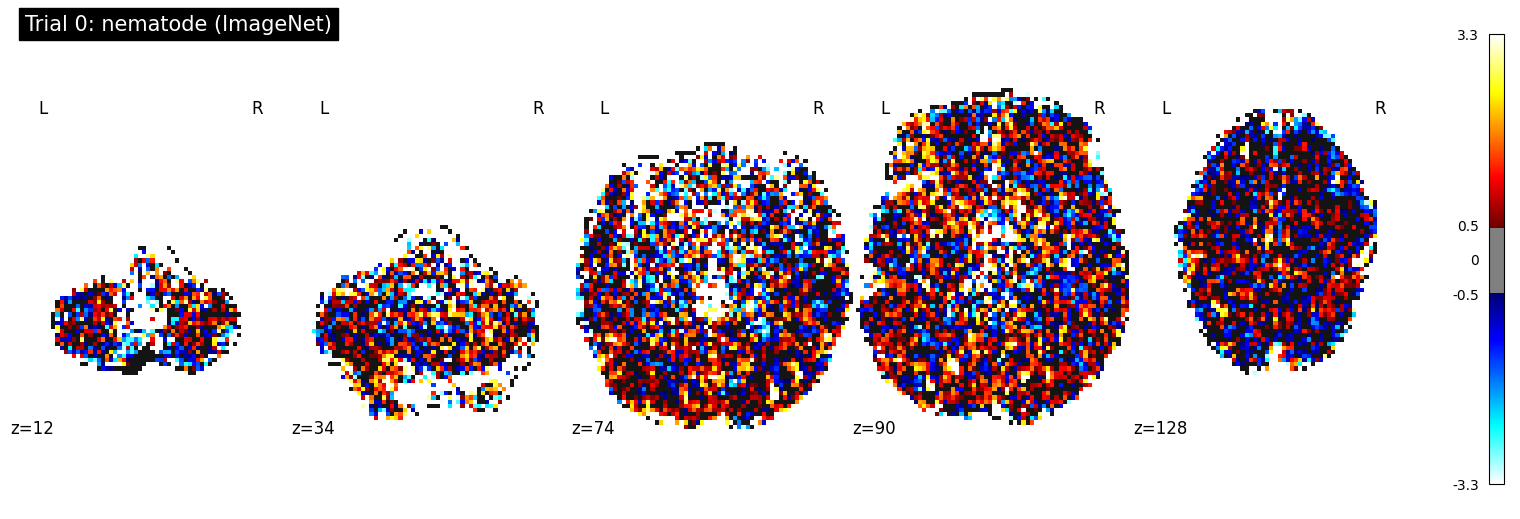


--- Trial 2 ---
Object: pretzel
Dataset: ImageNet
Filename: n07695742_5848.JPEG
✓ Saved: beta_labeled_trial_2_pretzel.png


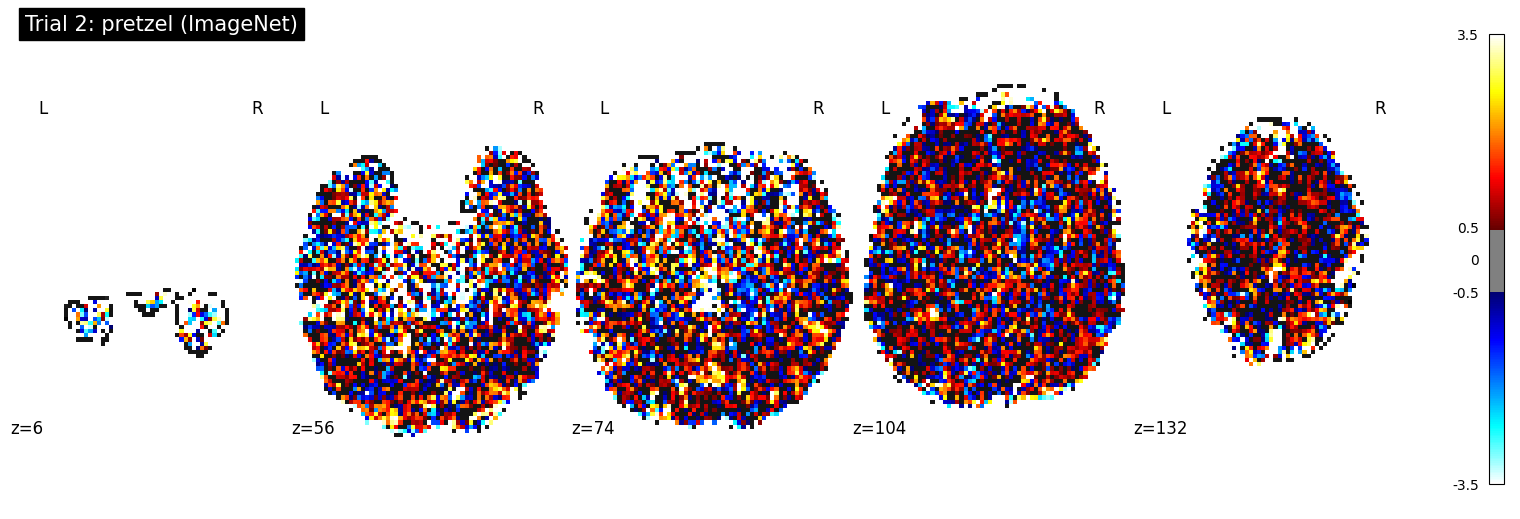


--- Trial 6 ---
Object: Tibetan_mastiff
Dataset: ImageNet
Filename: n02108551_26574.JPEG


/var/folders/wf/x89_kbv94dz4zpg4wy86jj4c0000gn/T/ipykernel_30509/1097590754.py:33: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  display = plotting.plot_stat_map(


✓ Saved: beta_labeled_trial_6_Tibetan_mastiff.png


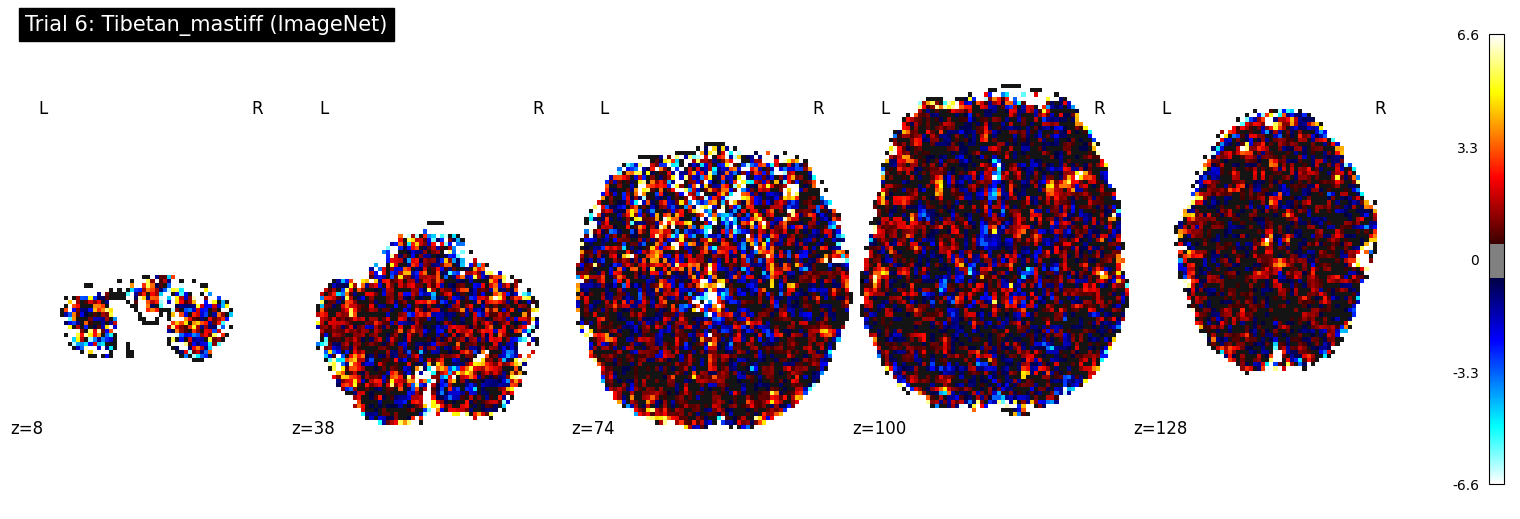


✓ VISUALIZATION WITH LABELS COMPLETE!


In [25]:
# Visualize a few examples with object labels

print("=" * 70)
print("BETA MAPS WITH OBJECT LABELS")
print("=" * 70)

# Pick a few interesting trials to visualize
trials_to_show = [0, 2, 6]  # e.g., nematode, pretzel, Tibetan_mastiff

for trial_idx in trials_to_show:
    print(f"\n--- Trial {trial_idx} ---")
    
    # Get info
    filename = events_glm_df[stim_col].iloc[trial_idx]
    object_label = events_glm_df['object_label'].iloc[trial_idx]
    dataset = events_glm_df['dataset_source'].iloc[trial_idx]
    
    print(f"Object: {object_label}")
    print(f"Dataset: {dataset}")
    print(f"Filename: {filename}")
    
    # Extract beta map
    beta_map_3d = image.index_img(beta_img, trial_idx)
    
    # Calculate statistics
    data = beta_map_3d.get_fdata()
    data_flat = data[~np.isnan(data)].flatten()
    vmax = np.percentile(np.abs(data_flat), 95)
    
    # Create visualization
    fig = plt.figure(figsize=(15, 5))
    
    display = plotting.plot_stat_map(
        beta_map_3d,
        bg_img=mean_beta,
        display_mode='z',
        cut_coords=5,
        title=f"Trial {trial_idx}: {object_label} ({dataset})",
        threshold=0.5,
        vmax=vmax,
        cmap='cold_hot',
        figure=fig,
        colorbar=True,
        black_bg=False,
        dim=-0.5
    )
    
    plt.savefig(f"beta_labeled_trial_{trial_idx}_{object_label}.png", dpi=150, bbox_inches='tight')
    print(f"✓ Saved: beta_labeled_trial_{trial_idx}_{object_label}.png")
    
    plt.show()

print("\n" + "=" * 70)
print("✓ VISUALIZATION WITH LABELS COMPLETE!")
print("=" * 70)

## Step 9: Download and Parse COCO Annotations

COCO annotations provide detailed object labels for each image. We'll download the instance annotations and map image IDs to object categories.

In [26]:
# Step 1: Download COCO 2014 Train Annotations
# This is a ~250MB file, so it may take a minute or two

coco_annotations_file = os.path.join(mappings_dir, "instances_train2014.json")

if not os.path.exists(coco_annotations_file):
    print("Downloading COCO 2014 train annotations...")
    print("(This is ~250MB and may take 1-2 minutes)")
    
    coco_url = "http://images.cocodataset.org/annotations/annotations_trainval2014.zip"
    zip_file = os.path.join(mappings_dir, "coco_annotations.zip")
    
    try:
        # Download the zip file
        print("Downloading...")
        urllib.request.urlretrieve(coco_url, zip_file)
        print("✓ Downloaded")
        
        # Extract the annotations
        print("Extracting annotations...")
        import zipfile
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            # Extract only the train instances file
            zip_ref.extract('annotations/instances_train2014.json', mappings_dir)
        
        # Move to the right location
        import shutil
        extracted_file = os.path.join(mappings_dir, 'annotations', 'instances_train2014.json')
        shutil.move(extracted_file, coco_annotations_file)
        
        # Clean up
        os.remove(zip_file)
        os.rmdir(os.path.join(mappings_dir, 'annotations'))
        
        print(f"✓ Extracted and saved: {coco_annotations_file}")
        
    except Exception as e:
        print(f"✗ Error downloading COCO annotations: {e}")
        print("You can manually download from: http://images.cocodataset.org/annotations/annotations_trainval2014.zip")
else:
    print(f"✓ COCO annotations already exist: {coco_annotations_file}")

# Check file size
if os.path.exists(coco_annotations_file):
    file_size_mb = os.path.getsize(coco_annotations_file) / (1024 * 1024)
    print(f"  File size: {file_size_mb:.1f} MB")

(This is ~250MB and may take 1-2 minutes)
Downloading...
✓ Downloaded
Extracting annotations...
✓ Extracted and saved: label_mappings/instances_train2014.json
  File size: 317.2 MB


In [27]:
# Step 2: Parse COCO annotations to create image_id -> objects mapping

if os.path.exists(coco_annotations_file):
    print("Loading COCO annotations (this may take 10-20 seconds)...")
    
    with open(coco_annotations_file, 'r') as f:
        coco_data = json.load(f)
    
    print("✓ COCO annotations loaded")
    
    # Create category ID to name mapping
    coco_categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
    print(f"\nTotal COCO categories: {len(coco_categories)}")
    print(f"Example categories: {list(coco_categories.values())[:10]}")
    
    # Create image_id -> list of objects mapping
    print("\nBuilding image_id to objects mapping...")
    coco_image_to_objects = {}
    
    for annotation in coco_data['annotations']:
        image_id = annotation['image_id']
        category_id = annotation['category_id']
        category_name = coco_categories[category_id]
        
        if image_id not in coco_image_to_objects:
            coco_image_to_objects[image_id] = []
        
        # Avoid duplicates
        if category_name not in coco_image_to_objects[image_id]:
            coco_image_to_objects[image_id].append(category_name)
    
    print(f"✓ Mapped {len(coco_image_to_objects)} COCO images to objects")
    
    # Show example
    example_id = list(coco_image_to_objects.keys())[0]
    print(f"\nExample: Image {example_id} contains: {coco_image_to_objects[example_id]}")
    
else:
    print("⚠ COCO annotations file not found. Skipping COCO mapping.")
    coco_image_to_objects = {}

Loading COCO annotations (this may take 10-20 seconds)...
✓ COCO annotations loaded

Total COCO categories: 80
Example categories: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']

Building image_id to objects mapping...
✓ Mapped 82081 COCO images to objects

Example: Image 480023 contains: ['hot dog', 'person']


In [34]:
# Step 3: Update label extraction function to use COCO mappings
import re

def get_label_from_filename(stim_file):
    """
    Extract human-readable label from stimulus filename.
    Handles ImageNet, COCO, and Scene datasets.
    """
    filename = os.path.basename(stim_file)
    
    # ImageNet format: "n########_#####.JPEG"
    if filename.startswith('n') and '_' in filename:
        synset_id = filename.split('_')[0]  # Extract n########
        if 'imagenet_synset_to_label' in globals() and synset_id in imagenet_synset_to_label:
            return imagenet_synset_to_label[synset_id]
        return 'ImageNet_object'
    
    # COCO format: "COCO_train2014_000000[id].jpg"
    elif 'COCO' in filename or 'coco' in filename.lower():
        match = re.search(r'(\d{6,12})', filename)
        if match and coco_image_to_objects:
            image_id = int(match.group(1))
            if image_id in coco_image_to_objects:
                objects = coco_image_to_objects[image_id]
                # Return comma-separated list of objects
                return ', '.join(objects[:3])  # Limit to first 3 objects for readability
        return 'COCO_image'
    
    # Scene format: "scenename###.jpg" or similar
    else:
        # Extract scene name (remove numbers and extension)
        scene_name = re.sub(r'\d+', '', filename)  # Remove digits
        scene_name = os.path.splitext(scene_name)[0]  # Remove extension
        if scene_name:
            # Convert to title case with spaces before capitals
            scene_name = re.sub(r'([a-z])([A-Z])', r'\1 \2', scene_name)
            return f"Scene: {scene_name.title()}"
        return 'Scene'
    
    # Default
    return 'Unknown'

print("✓ Updated get_label_from_filename() function with COCO support")

✓ Updated get_label_from_filename() function with COCO support


In [35]:
# Step 4: Re-extract labels with COCO support

print("Updating labels with COCO mappings...")
events_glm_df['object_label'] = events_glm_df['stim_file'].apply(get_label_from_filename)

# Show summary by dataset
print("\n=== Label Extraction Summary ===")
for dataset_type in events_glm_df['dataset_source'].unique():
    subset = events_glm_df[events_glm_df['dataset_source'] == dataset_type]
    print(f"\n{dataset_type} ({len(subset)} images):")
    print(subset[['stim_file', 'object_label']].to_string(index=False))

# Count label types
print(f"\n=== Label Statistics ===")
label_counts = events_glm_df['object_label'].value_counts()
human_readable = len(events_glm_df[~events_glm_df['object_label'].str.contains('_image|Unknown', na=False)])
print(f"Human-readable labels: {human_readable}/{len(events_glm_df)}")
print(f"Still generic: {len(events_glm_df) - human_readable}")

Updating labels with COCO mappings...

=== Label Extraction Summary ===

ImageNet (15 images):
           stim_file    object_label
n01930112_19568.JPEG        nematode
n03733281_29214.JPEG            maze
 n07695742_5848.JPEG         pretzel
 n01917289_1429.JPEG     brain_coral
n02108551_26574.JPEG Tibetan_mastiff
n02111277_28582.JPEG    Newfoundland
 n04099969_6395.JPEG   rocking_chair
 n02747177_3947.JPEG          ashcan
n04371430_12487.JPEG swimming_trunks
  n01914609_785.JPEG     sea_anemone
 n02655020_1972.JPEG          puffer
 n04286575_5757.JPEG       spotlight
   n02966193_63.JPEG        carousel
 n01641577_1229.JPEG        bullfrog
n02443114_11782.JPEG         polecat

COCO (15 images):
                      stim_file                object_label
COCO_train2014_000000420713.jpg         banana, apple, vase
COCO_train2014_000000488558.jpg dining table, laptop, mouse
COCO_train2014_000000029114.jpg dining table, pizza, person
COCO_train2014_000000539340.jpg                  teddy